<p align="left">
  <img src="../escudo_uach.png" width="100">
</p>

# Estudio y Experimentación sobre  Amortiguamiento Viscoso

### Integrantes:

* Carlos Durán
* Sebastián Muñoz

## 0. Importar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

print("Ambiente listo para análisis de vibraciones")

Ambiente listo para análisis de vibraciones


# 1.  Introducción al Amortiguamiento Viscoso

## 1.1 Ecuación de Movimiento

Para introducir el concepto de amortiguamiento, el punto de partida fundamental es la ecuación de movimiento para un sistema de un grado de libertad. Cuando armamos el sistema compuesto por una masa ($m$), un resorte elástico con cierta rigidez ($k$) y un amortiguador viscoso ($c$), y luego aplicamos la Segunda Ley de Newton, este proceso resulta en la siguiente ecuación diferencial:

$$ m\ddot{x}(t) + c\dot{x}(t) + kx(t) = 0 $$

En donde:
*   **$m$** es la masa del sistema.
*   **$k$** representa la rigidez del resorte, el cual genera una fuerza restauradora conservativa proporcional al desplazamiento ($kx(t)$).
*   **$c$** es el **coeficiente de amortiguamiento viscoso**.
*   **$x(t)$, $\dot{x}(t)$ y $\ddot{x}(t)$** representan el desplazamiento, la velocidad y la aceleración de la masa, respectivamente.

En el caso de haber una fuerza externa involucrada, la ecuación diferencial cambia y resulta de la siguiente manera:

$$ m\ddot{x}(t) + c\dot{x}(t) + kx(t) = f(t) $$

En donde:

*   **$f(t)$** es la fuerza externa aplicada al sistema.

Como se vio en la ecuación de movimiento, la interacción de las 3 fuerzas principales resultantes de las características del sistema (Peso, rigidez y amortiguamiento) dicta cómo se comportará este en el tiempo. Una frecuencia natural se define como la frecuencia a la cual una estructura oscilará si es perturbada desde su posición de equilibrio y luego se le permite vibrar libremente.

La frecuencia natural no amortiguada ($\omega_n$) depende de la masa y de la rigidez del sistema. Se expresa como:

$\omega_n = \sqrt{\frac{k}{m}}$ [rad/s]

Para convertir este valor a Hertz (Hz), se utiliza  $f_n = \frac{\omega_n}{2\pi}$, resultando en la ecuación:

$f_n = \frac{1}{2\pi}\sqrt{\frac{k}{m}}$  [Hz]

En esta relación de frecuencias, se puede notar algo:
*   Si la rigidez ($k$) del sistema aumenta, la frecuencia natural aumenta.
*   Si la masa ($m$) del sistema aumenta, la frecuencia natural disminuye.

Por lo general, un sistema de este tipo, de manera práctica, nunca oscilará exactamente a su frecuencia natural, sino que el valor real variará un poco. A este valor práctico de oscilación se le conoce como **frecuencia natural amortiguada ($\omega_d$)**, la cual se calcula de la siguiente manera:

$$ \omega_d = \omega_n\sqrt{1-\zeta^2} $$

# 2. ¿Qué hace el amortiguamiento?
El término $c\dot{x}(t)$ representa la **fuerza de amortiguamiento**.

La característica que lo define es que genera una fuerza que se opone continuamente al movimiento, pero su magnitud no depende de cuánto se desplaza el sistema, sino de su rapidez: **la fuerza es directamente proporcional a la velocidad** de la masa ($\dot{x}$). A medida que el sistema se mueve, este mecanismo disipa la energía, lo que causa que el sistema eventualmente vuelva al reposo.

## 2.1 La razón de amortiguamiento ($\zeta$)
Para comprender el comportamiento del sistema independientemente de los valores físicos exactos de masa o rigidez, se empieza por dividir toda la ecuación de movimiento por la masa ($m$). Esto da como resultado la siguiente forma equivalente:

$$ \ddot{x}(t) + 2\zeta\omega_n\dot{x}(t) + \omega_n^2x(t) = 0 $$

En esta formulación matemática surgen dos propiedades dinámicas esenciales:
1.  **Frecuencia natural no amortiguada ($\omega_n$):** Calculada como $\sqrt{k/m}$, indica la tendencia de oscilación del sistema si no hubiera fricción.
2.  **Razón de amortiguamiento ($\zeta$):** Es una cantidad adimensional clave que se define como $\zeta = \frac{c}{2m\omega_n}$.

## 2.2 Casos de Amortiguamiento
El factor $\zeta$ determina la forma en que el sistema de masa, resorte y amortiguador se desplazará tras recibir un impacto o fuerza inicial:

*   **Sistema Subamortiguado ($0 < \zeta < 1$):** El sistema efectúa oscilaciones que cruzan el punto de equilibrio repetidamente, pero la amplitud de cada ciclo decae gradualmente en forma de una envolvente exponencial hasta extinguirse.

*   **Amortiguamiento Crítico ($\zeta = 1$):** En este caso se disipa la energía de forma tan eficaz, que la masa regresa a su posición de reposo en el menor tiempo posible, sin llegar a oscilar realmente.

*   **Sistema Sobreamortiguado ($\zeta > 1$):** El sistema regresa muy lentamente a su posición original, también sin oscilar.

## 3. Respuesta en el tiempo para una vibración libre amortiguada

Una forma simple de la respuesta de una vibración de este tipo, es la siguiente:

$
x(t) = x_0 e^{-\zeta \omega_n t}\cos(\omega_d t)
$

donde:

- $x_0$ es el desplazamiento inicial;
- $\zeta$ es la razón de amortiguamiento;
- $\omega_n$ es la frecuencia natural angular;
- $\omega_d$ es la frecuencia angular amortiguada.

# 4. Densidad Espectral de Potencia (PSD)

Una vez ya disponible la visualización de la señal en el tiempo, es bueno y útil analizar la señal en el dominio de la frecuencia. Para esto se emplea la Densidad Espectral de Potencia (PSD), la cual permite observar cómo se distribuye la energía de la señal a lo largo de las distintas frecuencias.

La PSD permite identificar las frecuencias dominantes en las que oscila el sistema. En una vibración libre amortiguada, el peak de la curva de densidad espectral aparecerá muy cerca de la frecuencia natural del sistema.

Las propiedades físicas del sistema (masa, rigidez y amortiguamiento) se pueden notar visualmente, esto gracias a que cualquier alteración en el sistema, como una pérdida de rigidez por daño, se verá reflejada como un desplazamiento del peak en el gráfico de la densidad espectral.

El método que se utiliza para estimar la PSD en este notebook es el Método de Welch.

## 5. Experimentación Correspondiente

### 5.1 Parámetros iniciales y frecuencias

In [2]:
# Parámetros físicos del sistema
mass = 10.0          # kg
stiffness = 4000.0   # N/m
damping_ratio = 0.03 # 3%

# Parámetros de simulación
sampling_frequency = 200.0 # Hz
duration = 20.0            # seconds
initial_displacement = 0.01 # m

# Frecuencia natural
omega_n = np.sqrt(stiffness / mass)      # rad/s
fn_hz = omega_n / (2 * np.pi)            # Hz

# Frecuencia natural amortiguada
omega_d = omega_n * np.sqrt(1 - damping_ratio**2)
fd_hz = omega_d / (2 * np.pi)

print(f"Frecuencia natural no amortiguada fn = {fn_hz:.3f} Hz")
print(f"Frecuencia natural amortiguada fd = {fd_hz:.3f} Hz")

Frecuencia natural no amortiguada fn = 3.183 Hz
Frecuencia natural amortiguada fd = 3.182 Hz


### 5.2 Adición de ruido para una simulación más similar a la práctica

La incerteza en la medición se introduce como ruido aditivo, y este valor controla la cantidad de ruido que se agrega a la señal limpia, esto se añade para simular una situación real, ya que una grabación siempre tiene al menos un poco de ruido adicional a la señal objetivo de grabación. Esto se hace a través de un valor generado aleatoriamente y un valor llamado "Desviación estándar del ruido (noise_std)" que se representa como un porcentaje de la amplitud máxima de la señal limpia.


In [3]:
rng = np.random.default_rng(42)

t = np.arange(0, duration, 1 / sampling_frequency)

x_clean = initial_displacement * np.exp(-damping_ratio * omega_n * t) * np.cos(omega_d * t)

noise_std = 0.02
noise = rng.normal(
    loc=0.0,
    scale=noise_std * np.max(np.abs(x_clean)),
    size=len(t)
)

x_noisy = x_clean + noise

print(f"Número de muestras: {len(t)}")
print(f"Duración: {duration} s")
print(f"Frecuencia de muestreo: {sampling_frequency} Hz")

Número de muestras: 4000
Duración: 20.0 s
Frecuencia de muestreo: 200.0 Hz


# 6. Respuesta de vibración libre a través del tiempo

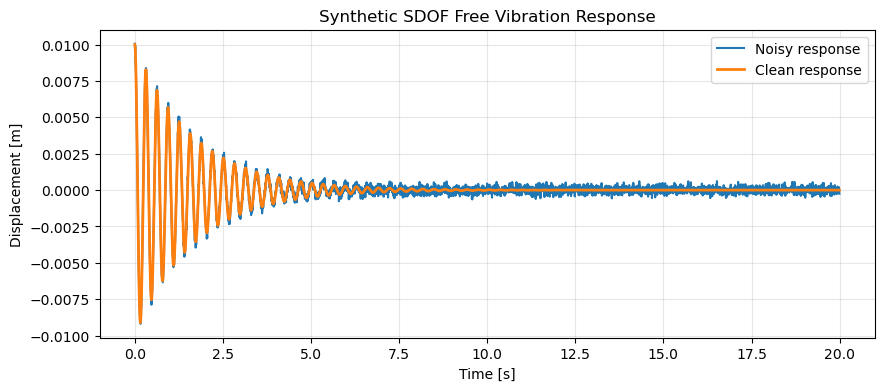

In [4]:

# Si se quiere ver una parte específica de la señal, se pueden definir los índices de inicio y final en función del tiempo:
# t1 = 2.0
# t2 = 2.5
# inicio = int(t1 * sampling_frequency)
# final = int(t2 * sampling_frequency)
# Y cambiar a esto:
# plt.plot(t[inicio:final], x_noisy[inicio:final], label="Noisy response")
# plt.plot(t[inicio:final], x_clean[inicio:final], linewidth=2, label="Clean response")

plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response")
plt.plot(t, x_clean, linewidth=2, label="Clean response")
plt.title("Synthetic SDOF Free Vibration Response")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 7. Método de Welch para la PSD

In [5]:
frequencies, psd = welch(
    x_noisy,
    fs=sampling_frequency,
    nperseg=1024,
    noverlap=512
)

dominant_frequency = frequencies[np.argmax(psd)]

print(f"Frecuencia natural teórica: {fn_hz:.3f} Hz")
print(f"Frecuencia dominante estimada desde PSD: {dominant_frequency:.3f} Hz")

Frecuencia natural teórica: 3.183 Hz
Frecuencia dominante estimada desde PSD: 3.125 Hz


### 7.1 Visualización de la PSD

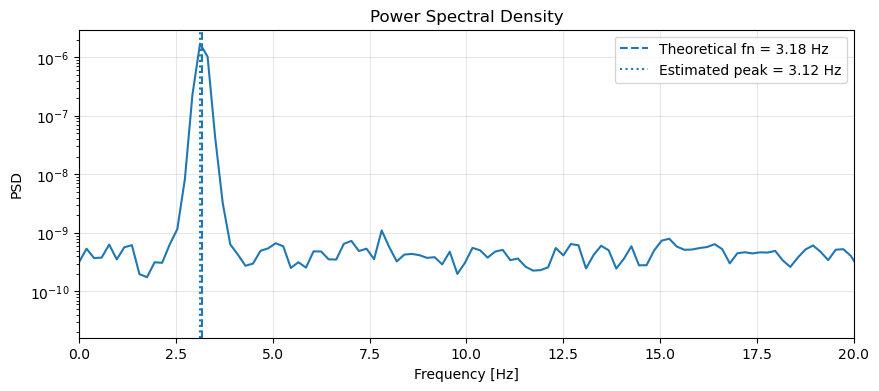

In [6]:
plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd)
plt.axvline(fn_hz, linestyle="--", label=f"Theoretical fn = {fn_hz:.2f} Hz")
plt.axvline(dominant_frequency, linestyle=":", label=f"Estimated peak = {dominant_frequency:.2f} Hz")
plt.title("Power Spectral Density")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 8. Preguntas para Marcos

1. ¿Qué ocurre con la frecuencia natural si aumenta la rigidez?
2. ¿Qué ocurre con la frecuencia natural si aumenta la masa?
3. ¿Qué ocurre con la señal temporal si aumenta el amortiguamiento?
4. ¿Por qué la frecuencia dominante estimada desde la PSD no coincide exactamente con la frecuencia teórica?
5. ¿Cómo podría cambiar esta respuesta si la estructura tuviera daño o pérdida de rigidez?


### 8.1 Respuestas:

1. Considerando que la frecuencia natural es:

$ f_n = \frac{1}{2\pi}\sqrt{\frac{k}{m}} $

Entonces se puede decir que, al presentar un aumento en la rigidez, la frecuencia natural aumenta también. Igual se puede notar esto cmabiando el valor de la rigidez en la sección de parámetros.

2. Considerando lo mismo que en la pregunta anterior, podemos decir que, al presentar un aumento en la masa, la frecuencia natural, en este caso, disminuye. Se puede verificar de la misma manera que la anterior pregunta.

3. Si se aumenta el amortiguamiento, la señal temporal pierde amplitud más rápido que con un amortiguamiento menor. Es decir, la intensidad de la señal comienza a decaer antes en el tiempo. Esto se puede comprobar en la sección de experimentaciones.

4. Esto se debe a la incerteza introducida al sumar ruido aleatorio a la señal limpia para simular una medición experimental real, y también se debe a que la PSD es una aproximación obtenida mediante el cálculo numérico del método de Welch.

5. Una caída en la rigidez causaría una disminución en la frecuencia natural del sistema y el peak dominante en la gráfica de la PSD se desplazaría hacia frecuencias más bajas. Al disminuir la rigidez y visualizar la PSD, se puede notar esto.
